In [1]:
%load_ext autoreload
%autoreload 2

In [175]:
import os
import sys
import torch
import numpy as np
from clustpy.deep.neural_networks.feedforward_autoencoder import FeedforwardAutoencoder

sys.path.append("/export/share/peters57dm/Verbund/deepsync/experiments/")
from helper.tracker import (
    AttractionRepellingLossTracker,
    AESyncLossTracker,
    EvaluationTracker,
)
from helper.datasets import (
    load_example,
    load_usps,
    load_htru,
    load_pendigits,
    load_optdigits,
    load_mnist,
    load_letterrecognition,
    load_cmu_faces,
    load_coil20,
    load_coil100,
    load_har,
    load_mice,
    load_synth_high,
    load_synth_low,
    load_weizmann,
    load_gaussian_blobs,
    load_cifar10,
    load_cifar100,
    load_fmnist,
    load_data,
)

sys.path.append("/export/share/peters57dm/Verbund/deepsync/")
from DeepSynC.helper import (
    # label assignment
    knn_assign_unlabeled_points,
    mahalanobis_assign_unlabeled_points,
    euclidean_assign_unlabeled_points,
    knn_average_assign_unlabeled_points,
    vote_of_two_knn_methods,
    # loss functions
    attraction_repelling_loss,
    ae_sync_loss,
)
from DeepSynC.ablation_version import deep_sync_model_ship
from helper.deep import (
    detect_device,
    load_pretrained_model,
    get_train_and_testloader,
)
from helper.utils import save_dict_as_json

In [182]:
import traceback


def run(k=25, percent=0.1, n_check=3, T_stop=3, id=0, model_id=0, force=True):
    print("")
    try:
        device = "cuda"  # detect_device()
        deepsync_kwargs = {
            "device": device,
            "training_iterations": 300,
            "k": k,
            "percent": percent,
            "n_check": n_check,
            "T_stop": T_stop,
            "id": id,
        }

        experiment_params = {
            "loss_funs": [
                ("ae_sync_loss", ae_sync_loss),
                # ("att_rep_loss", attraction_repelling_loss),
            ],  # number of loss functions must be equal to # number of losses trackers
            "batch_loss_trackers": [
                AESyncLossTracker,
                # AttractionRepellingLossTracker,
            ],
            "evaluation_tracker": EvaluationTracker,
            "datasets": [
                # load_example,
                # load_mice,
                load_optdigits,
                # load_har,
                # load_usps,
                # load_htru,
                # load_pendigits,
                # load_letterrecognition,
                # load_coil20,
                # load_mnist,
            ],
            "label_assignment_methods": [
                ("knn_label_assignment", knn_assign_unlabeled_points),
                # ("mahalanobis_label_assignment", mahalanobis_assign_unlabeled_points),
                # ("knn_average_dist_label_assignment", knn_average_assign_unlabeled_points),
                # ("vote_knn_methods", vote_of_two_knn_methods),
                # ("euclidean_label_assignment", euclidean_assign_unlabeled_points),
            ],
        }
        assert len(experiment_params["loss_funs"]) == len(experiment_params["batch_loss_trackers"])

        batch_size = 256
        base_path = (
            f"/export/share/peters57dm/Verbund/deepsync/results/ablations/{k=}##{percent=}##{n_check=}##{T_stop=}/"
        )

        model_name = "autoencoder.pth"
        max_embed_size = 10
        ae_layers = [256, 128, 64]
        learning_rate_deepsync = 1e-4

        pretrained_model_path = (
            "/export/share/peters57dm/Verbund/data/n-pretrained-models/mse_pretrained_models256-128-64"
        )
        deep_sync_model_name = "deep_sync_" + model_name
        deep_sync_path = os.path.join(base_path, "deep_sync.pth")

        loss_fns = experiment_params["loss_funs"]
        datasets_loading_methods = experiment_params["datasets"]
        loss_trackers = experiment_params["batch_loss_trackers"]
        labels_assignment_methods = experiment_params["label_assignment_methods"]

        # Create Experiment Base Path
        os.makedirs(base_path, exist_ok=True)

        for lf, LossTracker in zip(loss_fns, loss_trackers):
            lf_name, loss_fun_method = lf
            lf_path = os.path.join(base_path, lf_name)
            os.makedirs(lf_path, exist_ok=True)

            for lam in labels_assignment_methods:
                label_assignment_method_name, label_assignment_method = lam
                lam_path = os.path.join(lf_path, label_assignment_method_name)
                os.makedirs(lam_path, exist_ok=True)

                print(f"Loss: {lf_name} - Label Assignment: {label_assignment_method_name} - Device: {device}")
                for ds_loader in datasets_loading_methods:
                    try:
                        data, gt_labels, data_name = load_data(ds_loader)
                        trainloader, testloader = get_train_and_testloader(data, gt_labels, batch_size)
                        # print(f"\n\nDataset: {data_name}")
                    except:  # handling any reason for this particular dataset loading failure
                        print(f"Loading {data_name} failed. Continue to next experiment")
                        continue
                    dataset_experiment_path = os.path.join(lam_path, data_name)
                    os.makedirs(dataset_experiment_path, exist_ok=True)

                    # experiment_directory_path = os.path.join(dataset_experiment_path, 'exp_{0:02}'.format(exp_i)) # because we don't do experiment repetitions, but we use different pretrained models.
                    experiment_directory_path = os.path.join(dataset_experiment_path, "model_{0:02}".format(model_id))
                    os.makedirs(experiment_directory_path, exist_ok=True)

                    eval_tracker_path = f"/export/share/peters57dm/Verbund/deepsync/results/ablations/k={k}##percent={percent}##n_check={n_check}##T_stop={T_stop}/{lf_name}/{label_assignment_method_name}/{data_name}/{"model_{0:02}".format(model_id)}/trackers/eval_tracker.json"
                    if os.path.exists(eval_tracker_path) and not force:
                        print(
                            f"{id+1}/{NR_COMB}: k={k}##percent={percent}##n_check={n_check}##T_stop={T_stop}/{lf_name}/{label_assignment_method_name}/{data_name}/{"model_{0:02}".format(model_id)} -- Already exists"
                        )
                        continue

                    print(
                        f"{id+1}/{NR_COMB}: k={k}##percent={percent}##n_check={n_check}##T_stop={T_stop}/{lf_name}/{label_assignment_method_name}/{data_name}/{"model_{0:02}".format(model_id)} -- Compute..."
                    )

                    embedded_space_dim = min(data.shape[1], max_embed_size)
                    model = FeedforwardAutoencoder(
                        layers=[data.shape[1], ae_layers[0], ae_layers[1], ae_layers[2], embedded_space_dim]
                    ).to(device)
                    _mpath = os.path.join(pretrained_model_path, f"pretrained_{data_name}_{model_id}.pth")
                    model = load_pretrained_model(model, _mpath, device)

                    deepsync_kwargs["model"] = model
                    deepsync_kwargs["data"] = data
                    deepsync_kwargs["dataset_name"] = data_name
                    deepsync_kwargs["trainloader"], deepsync_kwargs["testloader"] = get_train_and_testloader(
                        data, gt_labels, batch_size
                    )
                    deepsync_kwargs["optimizer"] = torch.optim.Adam(model.parameters(), lr=learning_rate_deepsync)
                    deepsync_kwargs["loss_fn"] = loss_fun_method
                    deepsync_kwargs["labels_assignment_method"] = label_assignment_method
                    deepsync_kwargs["losses_tracker"] = LossTracker()
                    deepsync_kwargs["eval_tracker"] = EvaluationTracker(dataset_size=len(data))
                    deepsync_kwargs["directory"] = experiment_directory_path
                    deepsync_kwargs["deep_sync_model_path"] = os.path.join(
                        experiment_directory_path, deep_sync_model_name
                    )

                    model, labels_over_iterations = deep_sync_model_ship(**deepsync_kwargs)

    except Exception as e:
        print(f"ERROR -- {k=}, {percent=}, {n_check=}, {T_stop=}")
        print(f"Exception: {e}")
        traceback.print_exc()
        return

In [2]:
# default setting: k = 25, percent = 0.1, n_check = 3, T_stop stopping

# -) k nearest neigbour and for majority vote [5, 15, 25,35, 45]
# -) percent [0.05, 0.075, 0.1, 0.125, 0.15] --> check number of core points, do they capture the gt clusters
# -) n_check in [2,3,4,5]
# -) T_stop for early stopping [3,5,7,9]


NR_MODELS = 5
parameter_combinations = [
    {
        "k": [5, 15, 25, 35, 45],
        "percent": [0.1],
        "n_check": [3],
        "T_stop": [3],
    },
    {
        "k": [25],
        "percent": [0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.225, 0.25],
        "n_check": [3],
        "T_stop": [3],
    },
    {
        "k": [25],
        "percent": [0.1],
        "n_check": [2, 3, 4, 5, 6, 7],
        "T_stop": [3],
    },
    {
        "k": [25],
        "percent": [0.1],
        "n_check": [3],
        "T_stop": [3, 5, 7, 9, 11, 13],
    },
]

In [143]:
from itertools import product

unique_combinations = {
    tuple(zip(comb.keys(), values)) for comb in parameter_combinations for values in product(*comb.values())
}
unique_combinations = [dict(comb) for comb in unique_combinations]
unique_combinations = [dict({"model_id": model_id}, **d) for model_id in range(NR_MODELS) for d in unique_combinations]
unique_combinations = [dict({"id": id}, **comb) for (id, comb) in enumerate(unique_combinations)]

NR_COMB = len(unique_combinations)
print(NR_COMB)
unique_combinations

115


[{'id': 0, 'model_id': 0, 'k': 25, 'percent': 0.1, 'n_check': 4, 'T_stop': 3},
 {'id': 1, 'model_id': 0, 'k': 25, 'percent': 0.1, 'n_check': 5, 'T_stop': 3},
 {'id': 2, 'model_id': 0, 'k': 25, 'percent': 0.1, 'n_check': 3, 'T_stop': 9},
 {'id': 3, 'model_id': 0, 'k': 35, 'percent': 0.1, 'n_check': 3, 'T_stop': 3},
 {'id': 4, 'model_id': 0, 'k': 25, 'percent': 0.15, 'n_check': 3, 'T_stop': 3},
 {'id': 5, 'model_id': 0, 'k': 25, 'percent': 0.1, 'n_check': 3, 'T_stop': 5},
 {'id': 6, 'model_id': 0, 'k': 25, 'percent': 0.05, 'n_check': 3, 'T_stop': 3},
 {'id': 7, 'model_id': 0, 'k': 25, 'percent': 0.1, 'n_check': 7, 'T_stop': 3},
 {'id': 8, 'model_id': 0, 'k': 5, 'percent': 0.1, 'n_check': 3, 'T_stop': 3},
 {'id': 9,
  'model_id': 0,
  'k': 25,
  'percent': 0.075,
  'n_check': 3,
  'T_stop': 3},
 {'id': 10,
  'model_id': 0,
  'k': 25,
  'percent': 0.1,
  'n_check': 3,
  'T_stop': 11},
 {'id': 11, 'model_id': 0, 'k': 25, 'percent': 0.2, 'n_check': 3, 'T_stop': 3},
 {'id': 12,
  'model_id': 

In [ ]:
# import shutil
# folder_path = "/export/share/peters57dm/Verbund/deepsync/results/ablations/"
# if os.path.exists(folder_path):
#     shutil.rmtree(folder_path)

In [ ]:
from mpire.pool import WorkerPool

# n_jobs=20
# with WorkerPool(n_jobs=1, use_dill=True) as pool:
#     pool.map_unordered(run, unique_combinations)

for comb in unique_combinations:
    run(**comb)

In [ ]:
# run(k=25, percent=0.1, n_check=7, T_stop=3, model_id=1, force=True)


Loss: ae_sync_loss - Label Assignment: knn_label_assignment - Device: cuda
1/115: k=25##percent=0.1##n_check=7##T_stop=3/ae_sync_loss/knn_label_assignment/optdigits/model_01 -- Compute...


Initial clustering evalution:
AMI =  [0.981781659593262]
ARI =  [0.9806880322382032]
labeled points = [2440]/5620
-------------------------------------


dataset_name='optdigits',k=25,percent=0.1,n_check=7,T_stop=3:  17%|▏| 52/300 [00:44<03:32,

Early stopping after 52 iterations, the algorithm is not assigning any new points for 3 iterations.


In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_lineplot(
    df,
    x_axis,
    y_axis,
    grouping=None,
    order=[],
    x_range=(None, None),
    y_range=(None, None),
    x_label=None,
    y_label=None,
    # figsize=(15, 5),
    # figsize=(9, 4),
    figsize=(10, 6),
    dpi=200,
    # errorbar="se",
    errorbar=("ci", 75),
    highlight=1,
    highlight_size=2,
    red_legend_lables=[],
    metric_abbrev={},
    font_size=16,
    ncol=4,
    row_wise=True,
    palette=None,
    fig=None,
    ax=None,
    markersize=10,
    sizes=None,
    dashes=None,
    markers=None,
):
    """Plot a line plot for a dataframe."""
    plt.rcParams.update({"font.size": font_size})

    if fig is None:
        fig = plt.figure(
            figsize=figsize,
            dpi=dpi,
            layout="tight",
        )
    highlight -= 1

    if x_label is not None:
        df = df.rename(columns={x_axis: x_label})
        x_axis = x_label

    if y_label is not None:
        df = df.rename(columns={y_axis: y_label})
        y_axis = y_label

    if grouping is not None:
        if order is None:
            order = list(df[grouping].unique())
        for metric in order.copy():
            if metric not in df[grouping].unique():
                order.remove(metric)

    highlight_index = [highlight] + list(range(0, highlight)) + list(range(highlight + 1, len(order)))
    order = list(np.array(order)[highlight_index])

    def repeat(array):
        return array * ((len(order) - 1 + len(array)) // len(array))

    if markers is None:
        markers = ["p"] + repeat(["v", "^", "<", ">", "p", "P", "X", "d", "D", "H"])
    if palette is None:
        palette = ["black"] + repeat(sns.color_palette("bright"))
    if sizes is None:
        sizes = [highlight_size] + repeat([2])
    # sizes = np.array(sizes) * 2
    # sizes = np.array(sizes) / 2
    if dashes is None:
        dashes = [(1, 0)] + repeat([(1, 2), (4, 2), (3, 2, 1, 2)])

    ax = sns.lineplot(
        data=df,
        x=x_axis,
        y=y_axis,
        markers=dict(zip(order, markers)),
        markersize=markersize,
        hue=grouping,
        palette=dict(zip(order, palette)),
        hue_order=order[::-1],
        style=grouping,
        dashes=dict(zip(order, dashes)),
        size=grouping,
        sizes=dict(zip(order, sizes)),
        errorbar=errorbar,
        ax=ax,
    )

    ax.set_xlim(*x_range)
    ax.set_ylim(*y_range)

    ### Coloring of the plot
    ax.set_facecolor("white")
    ax.spines["bottom"].set_color("black")
    ax.spines["left"].set_color("black")
    ax.spines["right"].set_color("white")
    ax.spines["top"].set_color("white")
    ax.grid(color="lightgray")

    ### Legend
    handles, _ = ax.get_legend_handles_labels()
    inverse_index = np.empty(len(order), dtype=int)
    inverse_index[highlight_index] = np.arange(0, len(order))
    if row_wise:
        row_wise_index = sum((list(range(len(order))[i::ncol]) for i in range(ncol)), [])
    else:
        row_wise_index = list(range(len(order)))
    leg = ax.legend(
        handles=list(np.array(handles[::-1])[inverse_index][row_wise_index]),
        labels=list(np.array(order)[inverse_index][row_wise_index]),
        loc="center right",
        bbox_to_anchor=(1, 0.5),
        # loc="lower center",
        # bbox_to_anchor=(0.5, 1.05),
        # loc="upper center",
        # bbox_to_anchor=(0.5, 0),
        # fontsize=19,
        ncol=ncol,
    )
    for text in leg.get_texts():
        if text.get_text() in red_legend_lables:
            text.set_color("red")
        if text.get_text() in metric_abbrev:
            text.set_text(metric_abbrev[text.get_text()])

    frame = leg.get_frame()
    frame.set_facecolor("white")
    frame.set_edgecolor("black")

    return fig

In [145]:
unique_combinations

[{'id': 0, 'model_id': 0, 'k': 25, 'percent': 0.1, 'n_check': 4, 'T_stop': 3},
 {'id': 1, 'model_id': 0, 'k': 25, 'percent': 0.1, 'n_check': 5, 'T_stop': 3},
 {'id': 2, 'model_id': 0, 'k': 25, 'percent': 0.1, 'n_check': 3, 'T_stop': 9},
 {'id': 3, 'model_id': 0, 'k': 35, 'percent': 0.1, 'n_check': 3, 'T_stop': 3},
 {'id': 4, 'model_id': 0, 'k': 25, 'percent': 0.15, 'n_check': 3, 'T_stop': 3},
 {'id': 5, 'model_id': 0, 'k': 25, 'percent': 0.1, 'n_check': 3, 'T_stop': 5},
 {'id': 6, 'model_id': 0, 'k': 25, 'percent': 0.05, 'n_check': 3, 'T_stop': 3},
 {'id': 7, 'model_id': 0, 'k': 25, 'percent': 0.1, 'n_check': 7, 'T_stop': 3},
 {'id': 8, 'model_id': 0, 'k': 5, 'percent': 0.1, 'n_check': 3, 'T_stop': 3},
 {'id': 9,
  'model_id': 0,
  'k': 25,
  'percent': 0.075,
  'n_check': 3,
  'T_stop': 3},
 {'id': 10,
  'model_id': 0,
  'k': 25,
  'percent': 0.1,
  'n_check': 3,
  'T_stop': 11},
 {'id': 11, 'model_id': 0, 'k': 25, 'percent': 0.2, 'n_check': 3, 'T_stop': 3},
 {'id': 12,
  'model_id': 

In [10]:
from itertools import product
import json
import pandas as pd
import os

datasets = [
    "mice",
    "optdigits",
    "HAR",
    "USPS",
]
loss = "ae_sync_loss"
assignment = "knn_label_assignment"
model = "model_00"


parameter_combination_names = ["k", "percent", "n_check", "T_stop"]
ablation_studies = [
    dict(
        {"name": name, "dataset": dataset, "model": model_id},
        **dict(zip(comb.keys(), values)),
    )
    for model_id in range(NR_MODELS)
    for dataset in datasets
    for name, comb in zip(parameter_combination_names, parameter_combinations)
    for values in product(*comb.values())
]


for comb in ablation_studies:
    ablation_path = f"/export/share/peters57dm/Verbund/deepsync/results/ablations/k={comb["k"]}##percent={comb["percent"]}##n_check={comb["n_check"]}##T_stop={comb["T_stop"]}/{loss}/{assignment}/{comb["dataset"]}/{"model_{0:02}".format(comb["model"])}/trackers/eval_tracker.json"
    if not os.path.exists(ablation_path):
        continue
    with open(ablation_path, "r") as f:
        data = json.load(f)
    comb["ari"] = data["ari_total"][-1]

df = pd.DataFrame(ablation_studies)
df

,name,dataset,model,k,percent,n_check,T_stop,ari
0,k,mice,0,5,0.1,3,3,0.253832
1,k,mice,0,15,0.1,3,3,0.303658
2,k,mice,0,25,0.1,3,3,0.258540
3,k,mice,0,35,0.1,3,3,0.255885
4,k,mice,0,45,0.1,3,3,0.248850
...,...,...,...,...,...,...,...,...
515,T_stop,USPS,4,25,0.1,3,5,0.735768
516,T_stop,USPS,4,25,0.1,3,7,0.739412
517,T_stop,USPS,4,25,0.1,3,9,0.730194
518,T_stop,USPS,4,25,0.1,3,11,0.737586


In [12]:
df.to_csv("ablation_study.csv", index=False)

In [15]:
import pandas as pd
import numpy as np

df = pd.read_csv("ablation_study.csv")
parameter_combination_names = ["k", "percent", "n_check", "T_stop"]

datasets = [
    "mice",
    "optdigits",
    "HAR",
    "USPS",
]

In [122]:
!pwd

/export/share/peters57dm/Verbund/deepsync


In [ ]:
defaults = {"k": 25, "percent": 0.1, "n_check": 3, "T_stop": 3}

for i, parameter in enumerate(parameter_combination_names):
    df2 = df[df["name"] == parameter]

    fig = plt.figure(
        figsize=(10, 6),
        dpi=200,
        layout="tight",
    )
    ax = fig.gca()
    ax.axvline(x=defaults[parameter], color='red', linestyle='-', linewidth=2, alpha=0.6)

    fig = plot_lineplot(
        df=df2,
        x_axis=parameter,
        y_axis="ari",
        x_label=f"${parameter.replace("_", r"\_")}$",
        y_label="ARI",
        y_range=(0, 1),
        grouping="dataset",
        order=datasets,
        ncol=5,
        fig=fig,
    )
    ax.set_xticks(df2[parameter].unique())

    plt.savefig(f"results/imgs/parameter_ablations/{parameter}.pdf", format="pdf", bbox_inches="tight", pad_inches=0)

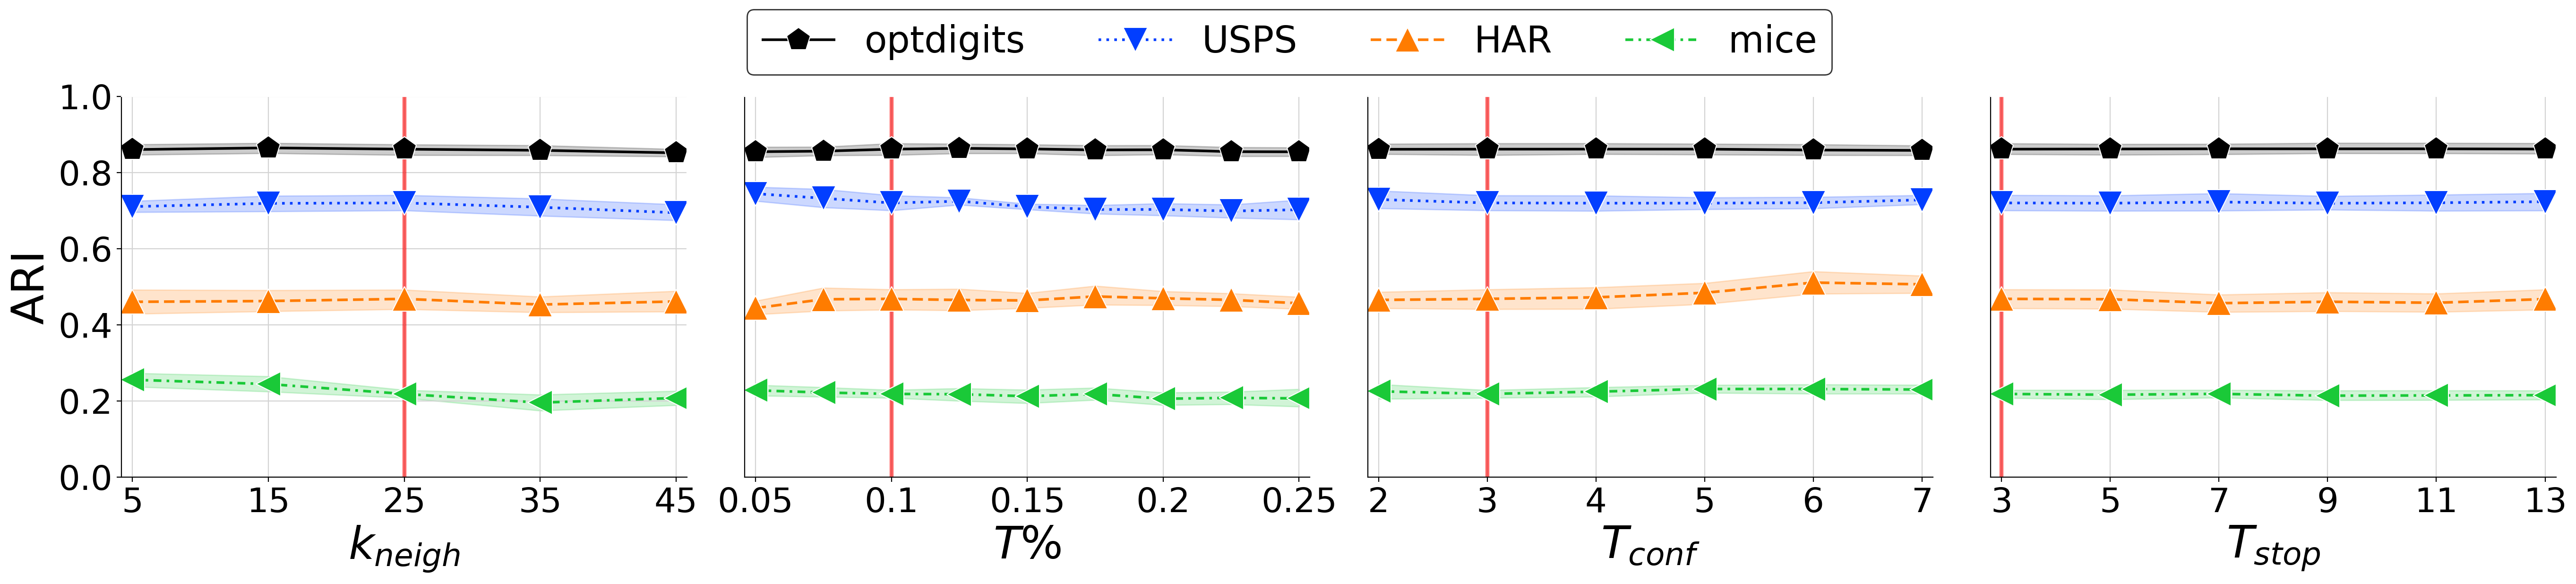

In [ ]:
import matplotlib.pyplot as plt

defaults = {"k": 25, "percent": 0.1, "n_check": 3, "T_stop": 3}
x_labels = {"k": r"$k_{neigh}$", "percent": r"$T\%$", "n_check": r"$T_{conf}$", "T_stop": r"$T_{stop}$"}

# Adjust rows and columns based on how many plots you need
rows, cols = 1, 4

fig, axes = plt.subplots(
    nrows=rows,
    ncols=cols,
    figsize=(10*2.74, 5.5),
    dpi=200,
    layout="tight",
)

for i, parameter in enumerate(parameter_combination_names):
    ax = axes[i]
    df2 = df[df["name"] == parameter]

    ax.axvline(x=defaults[parameter], color="red", linestyle="-", linewidth=3, alpha=0.6)
    x_range=(df2[parameter].min(), df2[parameter].max())
    x_abs = x_range[1] - x_range[0]
    x_range = x_range[0] - 0.02*x_abs, x_range[1] + 0.02*x_abs

    plot_lineplot(
        df=df2,
        x_axis=parameter,
        y_axis="ari",
        x_label=x_labels[parameter],
        y_label="ARI",
        y_range=(0, 1),
        x_range=x_range,
        grouping="dataset",
        order=["optdigits", "USPS", "HAR", "mice"],
        ncol=1,
        fig=fig,
        ax=ax,
        font_size=28,
        markersize=19,
    )
    if i != 0:
        ax.set_yticks([])
        ax.set_ylabel("")
    ax.get_legend().remove()
    ax.set_xticks(df2[parameter].unique())
    if i == 1:
        ax.set_xticks(df2[parameter].unique()[::2], (df2[parameter].unique()[::2]), rotation=0)


for i, ax in enumerate(axes.flatten()):  # Use .ravel() or .flatten() to iterate over all subplots
    ax.xaxis.label.set_fontsize(34)
    ax.yaxis.label.set_fontsize(34)

    for label in ax.get_xticklabels():
        label.set_fontsize(26)
        # if i == 1:
        #     label.set_fontsize(22)

    for label in ax.get_yticklabels():
        label.set_fontsize(26)


handles, labels = axes[0].get_legend_handles_labels()
leg = fig.legend(
    handles=list(np.array(handles[::-1])),
    labels=list(np.array(["optdigits", "USPS", "HAR", "mice"])),
    loc="center right",
    bbox_to_anchor=(1.12, 0.58),  # X=center, Y=slightly above figure
    ncol=1,  # Number of columns in legend
    # loc="upper center",
    # bbox_to_anchor=(0.5, 1.15),
    # ncol=4,  # Number of columns in legend
)
frame = leg.get_frame()
frame.set_facecolor("white")
frame.set_edgecolor("black")

fig.tight_layout(pad=0.4)  # default is 1.0, reduce to squeeze plots closer

plt.savefig("results/imgs/parameter_ablations/ablation.pdf", format="pdf", bbox_inches="tight", pad_inches=0)